[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dz-web3/DS-Tech-2026spring/blob/main/Module7_LLM_Finetuning/Task2_Prompting_vs_Finetuning.ipynb)

**Click the badge above to open this notebook in Google Colab!**

# Task 2: Prompt Engineering — Can You Teach an LLM to Add?

**Data Science for Business (Technical) — Spring 2026**

---

## Learning Goals

In this task, you will:
1. **Discover** that LLMs struggle with arithmetic — and why
2. **Explore** how generation settings (temperature, output length) affect results
3. **Compare** zero-shot vs few-shot prompting
4. **Engineer** prompts to maximize accuracy on 7-digit addition

You will use **Llama 2** (Meta's open-source LLM) and see how prompt engineering can push a model beyond its apparent limits.

---

## What You Need to Do

1. **First**: Run all the cells to see the experiments
2. **Then**: Complete the 3 exercises below
3. **Finally**: Write your recommendation in the final section

**Estimated time**: 25-35 minutes

## Step 1: Setup

Enable GPU (Runtime > Change runtime type > **T4 GPU**), then run the cells below.

**Important**: Llama 2 is a gated model. Before running:
1. Go to [meta-llama/Llama-2-7b-chat-hf](https://huggingface.co/meta-llama/Llama-2-7b-chat-hf)
2. Log in to your Hugging Face account (or create one)
3. Fill out the access request form with your info and submit it
4. Wait for access to be granted (may take a few minutes to a few hours)
5. Make sure your `HF_TOKEN` is set up (see main notebook Section 1)

In [1]:
%%capture
!pip install transformers accelerate huggingface_hub -q

In [2]:
import torch
from huggingface_hub import login
from google.colab import userdata

# GPU check
if torch.cuda.is_available():
    print(f'GPU enabled: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU! Go to Runtime > Change runtime type > T4 GPU')

# HF login
try:
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=False)
    print('Logged in to Hugging Face.')
except Exception:
    print('HF_TOKEN not found. See the main notebook for setup.')

GPU enabled: NVIDIA RTX PRO 6000 Blackwell Server Edition
Logged in to Hugging Face.


## Step 2: Load Llama 2

We use **Llama 2 7B Chat** from Meta (2023). Unlike Qwen2.5 in the main notebook (which was specifically trained on math data), Llama 2 is a general-purpose chat model that struggles with arithmetic — perfect for seeing how prompt engineering helps.

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = 'meta-llama/Llama-2-7b-chat-hf'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map='auto',
)

print(f'Model loaded: {model_name}')
print(f'Parameters: ~{sum(p.numel() for p in model.parameters()) / 1e9:.1f} billion')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: meta-llama/Llama-2-7b-chat-hf
Parameters: ~6.7 billion


## Step 3: Helper Functions

Helper functions below:
- `generate()` — sends a prompt to the model with configurable settings
- `extract_number()` — pulls the answer out of verbose model responses
- `test_addition()` — runs a batch of problems and collects metrics

In [4]:
import re
import random
import numpy as np

def generate(prompt, max_new_tokens=50, temperature=0.01, do_sample=True):
    """Send a raw text prompt to the model and return generated text."""
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=max(temperature, 0.01),
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    # Stop at newline or 'Question' to prevent rambling
    raw = raw.split('\n')[0].strip()
    raw = raw.split('Question')[0].strip()
    return raw

def extract_number(text):
    """Extract the last number from model output (skips echoed operands)."""
    numbers = re.findall(r'\d+', text)
    return int(numbers[-1]) if numbers else None

def test_addition(prompt_fn, problems, max_new_tokens=50, temperature=0.01):
    """Test a prompt function on a list of (a, b) problems."""
    results = []
    for a, b in problems:
        prompt = prompt_fn(a, b)
        raw = generate(prompt, max_new_tokens=max_new_tokens, temperature=temperature)
        expected = a + b
        extracted = extract_number(raw)
        is_correct = (extracted == expected)
        error = abs(extracted - expected) if extracted is not None else expected
        is_clean = (raw.strip() == str(expected))
        results.append({'a': a, 'b': b, 'expected': expected, 'raw': raw,
                        'extracted': extracted, 'correct': is_correct,
                        'error': error, 'clean': is_clean})
    return results

def print_metrics(results, label=''):
    """Print accuracy, MAE, and format rate."""
    acc = sum(r['correct'] for r in results) / len(results)
    mae = np.mean([r['error'] for r in results])
    clean = sum(r['clean'] for r in results) / len(results)
    print(f'{label}  Accuracy: {acc:.0%}  |  MAE: {mae:,.0f}  |  Clean format: {clean:.0%}')
    return acc, mae, clean

# Sanity check
test = generate('Question: What is 3+7?\nAnswer:', max_new_tokens=10)
print(f'Sanity check: 3+7 -> "{test}"')
print('Helper functions ready.')

Sanity check: 3+7 -> "3 + 7 = 10."
Helper functions ready.


## The Challenge: Multi-Digit Addition

LLMs **predict the next token** — they don't compute. For small numbers (3+5), the model has seen enough examples in training data to "memorize" the pattern. For large numbers (1234567+7654321), it's essentially guessing.

We'll test Llama 2 on addition from **1 digit to 7 digits** and explore three levers:

| Lever | What it does |
|-------|-------------|
| **Prompt design** | What instructions/examples we give |
| **Output length** (`max_tokens`) | How many tokens the model can generate |
| **Temperature** | How "creative" vs "deterministic" the model is |

## Experiment 1: How Performance Degrades with Difficulty

We test zero-shot addition from 1-digit to 7-digit numbers. Watch the accuracy drop.

In [5]:
def zero_shot_prompt(a, b):
    return f'Question: What is {a}+{b}?\nAnswer:'

# Generate test problems at each digit level (20 per level for stable stats)
random.seed(42)
digit_results = {}

print('ZERO-SHOT ACCURACY BY DIGIT COUNT')
print('=' * 50)
for n_digits in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    lo = 10**(n_digits - 1) if n_digits > 1 else 1
    hi = 10**n_digits - 1
    problems = [(random.randint(lo, hi), random.randint(lo, hi)) for _ in range(20)]
    results = test_addition(zero_shot_prompt, problems, max_new_tokens=15)
    acc = sum(r['correct'] for r in results) / len(results)
    digit_results[n_digits] = {'acc': acc, 'results': results}
    print(f'  {n_digits}-digit:  {acc:.0%} correct  ({sum(r["correct"] for r in results)}/{len(results)})')

ZERO-SHOT ACCURACY BY DIGIT COUNT
  1-digit:  100% correct  (20/20)
  2-digit:  100% correct  (20/20)
  3-digit:  95% correct  (19/20)
  4-digit:  25% correct  (5/20)
  5-digit:  35% correct  (7/20)
  6-digit:  25% correct  (5/20)
  7-digit:  5% correct  (1/20)
  8-digit:  0% correct  (0/20)
  9-digit:  5% correct  (1/20)
  10-digit:  0% correct  (0/20)


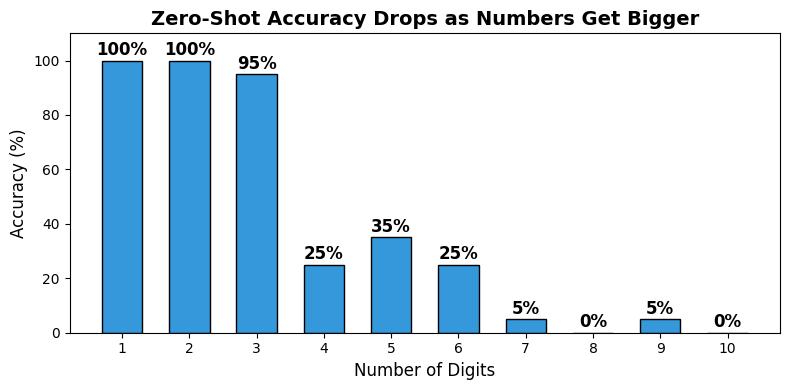


The model can handle small addition (memorized from training data).
For large numbers, it is predicting tokens, not computing.
As digit count grows, accuracy generally degrades.


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

digits = list(digit_results.keys())
accs = [digit_results[d]['acc'] * 100 for d in digits]

bars = ax.bar([str(d) for d in digits], accs, color='#3498db', edgecolor='black', width=0.6)
ax.set_xlabel('Number of Digits', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Zero-Shot Accuracy Drops as Numbers Get Bigger', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.0f}%',
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print('The model can handle small addition (memorized from training data).')
print('For large numbers, it is predicting tokens, not computing.')
print('As digit count grows, accuracy generally degrades.')

## Experiment 2: Output Length Matters

**Constraining the output length** (`max_tokens`) controls how many tokens the model can generate. For 7-digit addition, the answer is ~8 digits — so we only need 8-10 tokens. Setting `max_tokens` too low can truncate the answer; setting it too high wastes compute.

Think of it like telling an employee: "Give me just the number, in under 10 characters."

In [7]:
# Test 7-digit addition with different max_tokens settings
random.seed(42)
problems_7d = [(random.randint(1000000, 9999999), random.randint(1000000, 9999999)) for _ in range(20)]

print('7-DIGIT ADDITION: Effect of max_tokens')
print('=' * 65)

token_results = {}
for mt in [8, 15, 50, 100]:
    results = test_addition(zero_shot_prompt, problems_7d, max_new_tokens=mt)
    acc, mae, clean = print_metrics(results, f'  max_tokens={mt:<4}')
    token_results[mt] = {'acc': acc, 'mae': mae, 'clean': clean}

a, b = problems_7d[0]
print(f'\nSample outputs for: {a} + {b} = {a+b}')
for mt in [8, 50]:
    raw = generate(zero_shot_prompt(a, b), max_new_tokens=mt)
    print(f'  max_tokens={mt}: "{raw[:80]}"')

7-DIGIT ADDITION: Effect of max_tokens
  max_tokens=8     Accuracy: 5%  |  MAE: 3,833,638  |  Clean format: 5%
  max_tokens=15    Accuracy: 5%  |  MAE: 2,326,464  |  Clean format: 0%
  max_tokens=50    Accuracy: 10%  |  MAE: 443,272  |  Clean format: 0%
  max_tokens=100   Accuracy: 10%  |  MAE: 443,255  |  Clean format: 0%

Sample outputs for: 2867825 + 1419610 = 4287435
  max_tokens=8: "4287430"
  max_tokens=50: "4287430."


## Experiment 3: Temperature = Creativity vs Precision

**Temperature** controls randomness in the model's output:
- `temperature ≈ 0` → always picks the most likely next token (deterministic)
- `temperature = 1.0` → samples proportionally from all possible tokens (creative)

For arithmetic, we want **low temperature** — there's exactly one right answer.

In [8]:
print('7-DIGIT ADDITION: Effect of temperature')
print('=' * 65)

temp_results = {}
for temp in [0.01, 0.3, 0.7, 1.0]:
    results = test_addition(zero_shot_prompt, problems_7d, max_new_tokens=15, temperature=temp)
    acc, mae, clean = print_metrics(results, f'  temp={temp:<5}')
    temp_results[temp] = {'acc': acc, 'mae': mae}

print()
print('Low temperature = deterministic = generally better for tasks with one right answer.')
print('High temperature = creative = better for brainstorming, writing, etc.')
print('Note: for this task, the effect on accuracy may be small since the model')
print('struggles with large arithmetic regardless of temperature.')

7-DIGIT ADDITION: Effect of temperature
  temp=0.01   Accuracy: 5%  |  MAE: 2,326,447  |  Clean format: 0%
  temp=0.3    Accuracy: 0%  |  MAE: 2,327,235  |  Clean format: 0%
  temp=0.7    Accuracy: 0%  |  MAE: 4,177,825  |  Clean format: 0%
  temp=1.0    Accuracy: 0%  |  MAE: 5,295,043  |  Clean format: 0%

Low temperature = deterministic = generally better for tasks with one right answer.
High temperature = creative = better for brainstorming, writing, etc.
Note: for this task, the effect on accuracy may be small since the model
struggles with large arithmetic regardless of temperature.


## Experiment 4: Zero-Shot vs Few-Shot

Now the key comparison: does giving **examples in the prompt** help?

We test three strategies:
1. **Zero-shot**: No examples, just the question
2. **Few-shot (out-of-distribution)**: Examples use small numbers (1-digit)
3. **Few-shot (in-distribution)**: Examples use similar-sized numbers (7-digit)

 **In-distribution examples help much more** — the model needs to see examples that look like the actual task. Out-of-distribution examples (e.g., small numbers for a large-number task) can actually *hurt* performance by priming the model with the wrong format.

In [9]:
# Three prompt strategies (zero_shot_prompt defined in cell above)

def few_shot_small(a, b):
    """Out-of-distribution: 1-digit examples for a 7-digit task."""
    return ('Question: What is 3+7?\nAnswer: 10\n\n'
            'Question: What is 8+5?\nAnswer: 13\n\n'
            'Question: What is 6+9?\nAnswer: 15\n\n'
            f'Question: What is {a}+{b}?\nAnswer:')

def few_shot_large(a, b):
    """In-distribution: 7-digit examples with realistic carrying."""
    return ('Question: What is 1234567+7654321?\nAnswer: 8888888\n\n'
            'Question: What is 9876543+1234567?\nAnswer: 11111110\n\n'
            'Question: What is 3156283+4084597?\nAnswer: 7240880\n\n'
            'Question: What is 7035620+6824705?\nAnswer: 13860325\n\n'
            'Question: What is 5728189+3792177?\nAnswer: 9520366\n\n'
            f'Question: What is {a}+{b}?\nAnswer:')

print('7-DIGIT ADDITION: Comparing prompt strategies')
print('=' * 70)

comparison = {}
strategies = [('Zero-shot', zero_shot_prompt),
              ('Few-shot (small #s)', few_shot_small),
              ('Few-shot (large #s)', few_shot_large)]

for name, fn in strategies:
    results = test_addition(fn, problems_7d, max_new_tokens=15)
    acc, mae, clean = print_metrics(results, f'  {name:<22}')
    comparison[name] = {'acc': acc, 'mae': mae, 'results': results}

7-DIGIT ADDITION: Comparing prompt strategies
  Zero-shot               Accuracy: 5%  |  MAE: 2,326,464  |  Clean format: 0%
  Few-shot (small #s)     Accuracy: 0%  |  MAE: 92,304,390  |  Clean format: 0%
  Few-shot (large #s)     Accuracy: 20%  |  MAE: 349,026  |  Clean format: 20%


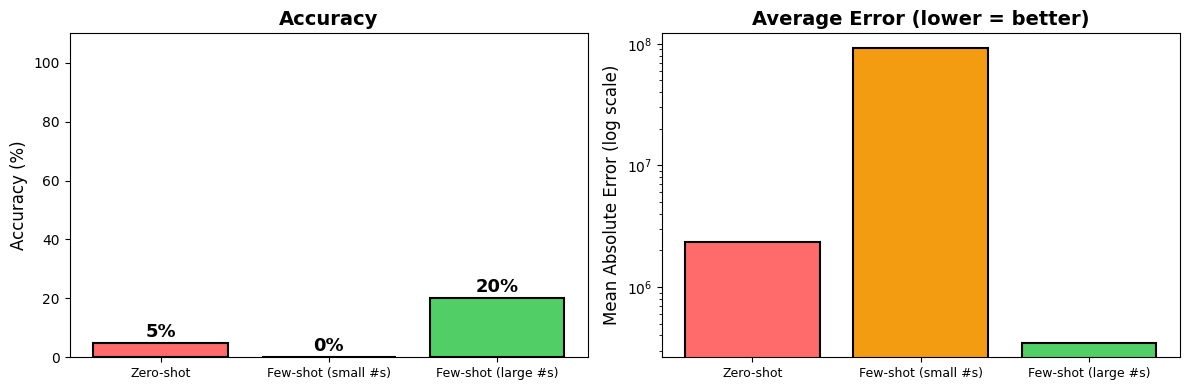


Key insight: In-distribution examples (7-digit) help much more than
out-of-distribution examples (1-digit).


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = list(comparison.keys())
accs = [comparison[n]['acc'] * 100 for n in names]
maes = [max(comparison[n]['mae'], 1) for n in names]  # avoid log(0)
colors = ['#ff6b6b', '#f39c12', '#51cf66']

axes[0].bar(range(len(names)), accs, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 110)
for i, v in enumerate(accs):
    axes[0].text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=13, fontweight='bold')

axes[1].bar(range(len(names)), maes, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylabel('Mean Absolute Error (log scale)', fontsize=12)
axes[1].set_title('Average Error (lower = better)', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print()
print('Key insight: In-distribution examples (7-digit) help much more than')
print('out-of-distribution examples (1-digit).')

In [11]:
# Detailed side-by-side for the last comparison
from IPython.display import HTML

html = '<h3>Detailed Results: 7-Digit Addition</h3>'
html += "<table style='width:100%; border-collapse:collapse; font-size:12px;'>"
html += "<tr style='background:#2c3e50; color:white;'>"
html += "<th style='padding:8px; border:1px solid #ddd;'>Problem</th>"
html += "<th style='padding:8px; border:1px solid #ddd;'>Correct</th>"
html += "<th style='padding:8px; border:1px solid #ddd;'>Zero-shot</th>"
html += "<th style='padding:8px; border:1px solid #ddd;'>Few-shot (small)</th>"
html += "<th style='padding:8px; border:1px solid #ddd;'>Few-shot (large)</th></tr>"

zr = comparison['Zero-shot']['results']
sr = comparison['Few-shot (small #s)']['results']
lr = comparison['Few-shot (large #s)']['results']

for z, s, l in zip(zr, sr, lr):
    html += '<tr>'
    html += f"<td style='padding:6px; border:1px solid #ddd; font-family:monospace;'>{z['a']} + {z['b']}</td>"
    html += f"<td style='padding:6px; border:1px solid #ddd; font-family:monospace; font-weight:bold;'>{z['expected']}</td>"
    for r in [z, s, l]:
        bg = '#f0fff0' if r['correct'] else '#fff5f5'
        ext = r['extracted'] if r['extracted'] is not None else '???'
        html += f"<td style='padding:6px; border:1px solid #ddd; background:{bg}; font-family:monospace;'>{ext}</td>"
    html += '</tr>'

html += '</table>'
display(HTML(html))

Problem,Correct,Zero-shot,Few-shot (small),Few-shot (large)
2867825 + 1419610,4287435,4287430,4287430,4287435
5614226 + 5108603,10722829,10720885,10720865,10720829
4744854 + 3341057,8085911,8085561,7085961,8085811
2719583 + 2458591,5178174,5174474,5171570,5178174
8078673 + 1533224,9611897,9609991,9611507,9611897
1499914 + 2571945,4071859,3671859,4071059,3671059
4668136 + 4903402,9571538,9561568,9561764,9561538
9478454 + 1445199,10923653,14451,10924453,10923443
4335942 + 8038374,12374316,12372096,123722062,12378806
4698379 + 8536477,13234856,13234254,13230274,13230856


## The Cost Tradeoff

Few-shot prompts include examples, which means **more tokens per request**. At scale, this adds up.

In [12]:
a, b = 1234567, 7654321
prompts = {
    'Zero-shot': zero_shot_prompt(a, b),
    'Few-shot (small)': few_shot_small(a, b),
    'Few-shot (large)': few_shot_large(a, b),
}

print('PROMPT LENGTH COMPARISON')
print('=' * 50)
for name, prompt in prompts.items():
    n_tokens = len(tokenizer.encode(prompt))
    print(f'  {name:<22} {n_tokens:>4} tokens')

cost_per_token = 0.25 / 1_000_000
queries_per_day = 1000
print(f'\n  At {queries_per_day:,} queries/day ($0.25/M tokens):')
for name, prompt in prompts.items():
    n_tokens = len(tokenizer.encode(prompt))
    monthly = n_tokens * queries_per_day * 30 * cost_per_token
    print(f'  {name:<22} ${monthly:.2f}/month')
print()
print('  Fine-tuning eliminates the example overhead -- examples are baked into the model.')

PROMPT LENGTH COMPARISON
  Zero-shot                25 tokens
  Few-shot (small)         76 tokens
  Few-shot (large)        197 tokens

  At 1,000 queries/day ($0.25/M tokens):
  Zero-shot              $0.19/month
  Few-shot (small)       $0.57/month
  Few-shot (large)       $1.48/month

  Fine-tuning eliminates the example overhead -- examples are baked into the model.


---

## Exercises (Optional)

The exercises below are **optional** — for those who want to explore further. The key concepts (prompt engineering, temperature, few-shot vs zero-shot) are all covered in the walkthrough above.

---

# Exercise 1: Tune the Settings

Experiment with `max_new_tokens` and `temperature` on 7-digit problems. Find the combination that gives the best accuracy.

**Hint**: What `max_tokens` makes sense for an answer that's ~8 digits long?

In [13]:
# YOUR CODE: Try different settings

# Change these values and re-run to see the effect
my_max_tokens = 50   # Try: 8, 10, 15, 50
my_temperature = 0.5  # Try: 0.01, 0.1, 0.5, 1.0

results = test_addition(zero_shot_prompt, problems_7d,
                        max_new_tokens=my_max_tokens,
                        temperature=my_temperature)
print_metrics(results, f'max_tokens={my_max_tokens}, temp={my_temperature}')

# Show a few examples
for r in results[:5]:
    status = 'CORRECT' if r['correct'] else 'WRONG'
    print(f'  {r["a"]} + {r["b"]} -> "{r["raw"][:50]}" extracted: {r["extracted"]}  ({status})')

max_tokens=50, temp=0.5  Accuracy: 20%  |  MAE: 368,400  |  Clean format: 0%
  2867825 + 1419610 -> "4286535." extracted: 4286535  (WRONG)
  5614226 + 5108603 -> "10720869." extracted: 10720869  (WRONG)
  4744854 + 3341057 -> "8085571." extracted: 8085571  (WRONG)
  2719583 + 2458591 -> "The sum of 2719583 and 2458591 is 5178174." extracted: 5178174  (CORRECT)
  8078673 + 1533224 -> "9609991." extracted: 9609991  (WRONG)


---

# Exercise 2: Design Your Own Few-Shot Prompt

Create a prompt with **3-5 examples** that maximizes accuracy on 7-digit addition.

Tips:
- Use in-distribution examples (7-digit numbers)
- Choose examples that demonstrate carrying
- Keep the format consistent (Question/Answer)

In [14]:
# YOUR CODE: Design your prompt

def my_prompt(a, b):
    return (
        # Add your examples here, e.g.:
        # 'Question: What is 1234567+7654321?\nAnswer: 8888888\n\n'
        # 'Question: What is ...?\nAnswer: ...\n\n'
        f'Question: What is {a}+{b}?\nAnswer:'
    )

# Test your prompt
results = test_addition(my_prompt, problems_7d, max_new_tokens=15)
print_metrics(results, 'Your prompt')

# Compare to baselines
print('\nBaselines for comparison:')
for name, fn in [('Zero-shot', zero_shot_prompt), ('Few-shot (large)', few_shot_large)]:
    base = test_addition(fn, problems_7d, max_new_tokens=15)
    print_metrics(base, f'  {name}')

Your prompt  Accuracy: 5%  |  MAE: 2,326,447  |  Clean format: 0%

Baselines for comparison:
  Zero-shot  Accuracy: 5%  |  MAE: 2,326,464  |  Clean format: 0%
  Few-shot (large)  Accuracy: 20%  |  MAE: 349,026  |  Clean format: 20%


---

# Exercise 3: Decision Framework

Based on what you've seen, fill out the table below.

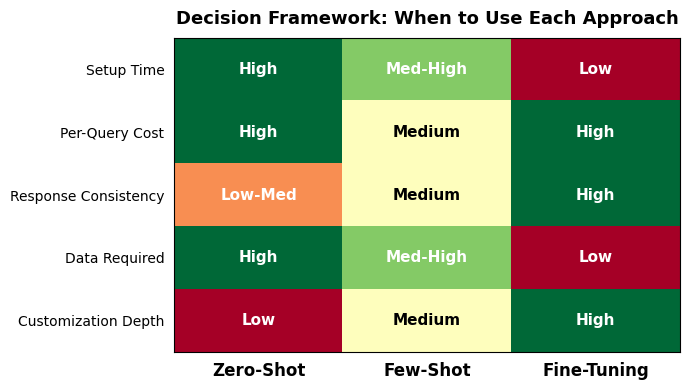

In [15]:
import matplotlib.pyplot as plt
import numpy as np

criteria = ['Setup Time', 'Per-Query Cost', 'Response Consistency', 'Data Required', 'Customization Depth']
approaches = ['Zero-Shot', 'Few-Shot', 'Fine-Tuning']

scores = np.array([
    [5, 4, 1],
    [5, 3, 5],
    [2, 3, 5],
    [5, 4, 1],
    [1, 3, 5],
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(scores, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)

ax.set_xticks(range(len(approaches)))
ax.set_xticklabels(approaches, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(criteria)))
ax.set_yticklabels(criteria, fontsize=10)
ax.tick_params(bottom=False, left=False)

labels_map = {1: 'Low', 2: 'Low-Med', 3: 'Medium', 4: 'Med-High', 5: 'High'}
for i in range(len(criteria)):
    for j in range(len(approaches)):
        color = 'white' if scores[i, j] <= 2 or scores[i, j] >= 4 else 'black'
        ax.text(j, i, labels_map[scores[i, j]], ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_title('Decision Framework: When to Use Each Approach', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### Your Answers:

| Scenario | Best Approach | Why? |
|----------|--------------|------|
| Quick prototype for a demo | *Your answer* | *Your reason* |
| Production system handling 1000s of queries/day | *Your answer* | *Your reason* |
| Highly regulated industry (healthcare, finance) | *Your answer* | *Your reason* |
| Small startup with limited budget | *Your answer* | *Your reason* |
| Enterprise with 100,000 historical examples | *Your answer* | *Your reason* |

---

**Summary Question**: A retail company asks you whether they should fine-tune a model or use few-shot prompting for their customer service bot. They have 500 historical customer-agent conversations. What is your recommendation and why?

*Your recommendation:*

---

## Summary: What We Learned

### Three Levers for Prompt Engineering

| Lever | What we found | Business takeaway |
|-------|--------------|-------------------|
| **Output length** (`max_tokens`) | Setting appropriate length avoids truncation and wasted compute | Always set output limits in production systems |
| **Temperature** | Low temperature = more precise; high = more creative | Use low temp for structured tasks, high for creative tasks |
| **In-context examples** | In-distribution examples help much more than generic ones | Your examples should match the actual use case |

### The Prompting to Fine-Tuning Spectrum

| Method | Pros | Cons | When to Use |
|--------|------|------|-------------|
| **Zero-shot** | No setup, instant | Generic, unreliable | Prototyping |
| **Few-shot** | Quick to iterate, no training | Extra tokens every call, limited by context window | MVPs, moderate customization |
| **Fine-tuning** | Consistent, low per-call cost | Needs data + compute | Production, specialized domains |

**Key takeaway**: Start with prompting. Move to fine-tuning when you need consistency at scale.

---

## Congratulations!

You have completed Module 8. You now understand:
- How LLMs struggle with tasks they weren't trained on (like large-number arithmetic)
- How prompt engineering (examples, settings) can improve results without training
- The tradeoffs between prompting approaches and fine-tuning